In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
import optuna

In [2]:
df = pd.read_csv('missense_mutations.csv')

In [3]:
df

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
1,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
2,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
3,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
4,24384,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),675,BRCA2,HGNC:1101,Pathogenic/Likely pathogenic,1,"Jul 09, 2024",80358979,...,C,-,-,-,-,-,-,SCV000567107|SCV000607817|SCV001478276|SCV0015...,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,4185255,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),675,BRCA2,HGNC:1101,Likely pathogenic,1,"Jun 12, 2025",-1,...,C,-,-,-,-,-,-,SCV006298678,-,-
11230,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11231,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11232,4391609,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),672,BRCA1,HGNC:1100,Uncertain significance,0,"Jul 31, 2025",-1,...,G,-,-,-,-,-,-,SCV006554521,-,-


Sınıfları ikili hale dönüştürme

In [4]:
mapping = {
    'Benign': 0, 'Likely benign': 0, 'Benign/Likely benign': 0,
    'Pathogenic': 1, 'Likely pathogenic': 1, 'Pathogenic/Likely pathogenic': 1
}

In [5]:
df_filtered = df[df['ClinicalSignificance'].isin(mapping.keys())].copy()
df_filtered['target'] = df_filtered['ClinicalSignificance'].map(mapping)

Girdi özelliklerinin seçilmesi

In [6]:
features = [
    'GeneSymbol', 'Start', 'NumberSubmitters',
    'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'Origin', 'ReviewStatus'
]
X = df_filtered[features].copy()
y = df_filtered['target']

Kategorik verileri sayısal bir şekle çevirme işlemi

In [7]:
X = pd.get_dummies(X, columns=['GeneSymbol', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'Origin', 'ReviewStatus'])

In [8]:
print(X.isnull().sum())

Start                                                                0
NumberSubmitters                                                     0
GeneSymbol_BRCA1                                                     0
GeneSymbol_BRCA2                                                     0
ReferenceAlleleVCF_A                                                 0
ReferenceAlleleVCF_C                                                 0
ReferenceAlleleVCF_G                                                 0
ReferenceAlleleVCF_T                                                 0
AlternateAlleleVCF_A                                                 0
AlternateAlleleVCF_C                                                 0
AlternateAlleleVCF_G                                                 0
AlternateAlleleVCF_T                                                 0
Origin_de novo;germline;not applicable;unknown                       0
Origin_germline                                                      0
Origin

Modelin test ve eğitim olarak ayrılması işlemi

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Normalizasyon işlemi

In [10]:
scaler = StandardScaler()
cols_to_scale = ['Start', 'NumberSubmitters']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

Modelin oluşturulması işlemi

In [11]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

Modelin eğitimi

In [13]:

history = model.fit(
    X_train, y_train,
    epochs=50,            # Veri üzerinden geçiş sayısı
    batch_size=32,        # Her adımda işlenecek örnek sayısı
    validation_split=0.2, # Eğitimin %20'sini doğrulama için ayır
    verbose=1,
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6746 - loss: 0.6402 - val_accuracy: 0.6048 - val_loss: 0.6069
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7022 - loss: 0.5580 - val_accuracy: 0.7016 - val_loss: 0.5526
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7554 - loss: 0.5364 - val_accuracy: 0.7863 - val_loss: 0.4999
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7667 - loss: 0.4968 - val_accuracy: 0.7984 - val_loss: 0.4489
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7817 - loss: 0.4819 - val_accuracy: 0.8024 - val_loss: 0.4143
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8125 - loss: 0.4274 - val_accuracy: 0.8347 - val_loss: 0.3844
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8112 - loss: 0.4207 - val_accuracy: 0.8387 - val_loss: 0.3772
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8238 - loss: 0.3919 - val_accuracy: 0.8468 - val_loss:

In [14]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [15]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[188,  14],
       [ 38,  70]], dtype=int64)

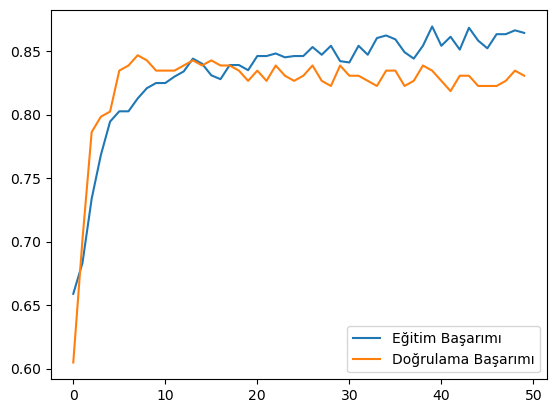

In [16]:
plt.plot(history.history['accuracy'], label='Eğitim Başarımı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarımı')
plt.legend()
plt.show()

In [17]:
acc = accuracy_score(y_test, y_pred)
acc

0.832258064516129

## Optuna Kullanımı 

In [18]:
def objective(trial):
    # 1. Hiperparametreler
    n_layers = trial.suggest_int('n_layers', 1, 3) 
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    model = Sequential()
    
    # 2. Mimari
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_l{i}', 32, 256, step=32)
        if i == 0:
            # Giriş katmanı: X_train.shape[1] öznitelik sayısını verir
            model.add(Dense(num_units, activation='relu', input_shape=(X_train.shape[1],)))
        else:
            model.add(Dense(num_units, activation='relu'))
        
        dropout_rate = trial.suggest_float(f'dropout_{i}', 0.1, 0.5)
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid')) 

    # 3. Derle ve Eğit
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy', # Kayıp fonksiyonu burada tanımlanır
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.2, 
        epochs=15, 
        batch_size=32, 
        verbose=0
    )

    # 4. Skor
    val_accuracy = history.history['val_accuracy'][-1]
    return val_accuracy

In [19]:
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())

[I 2026-03-22 17:42:13,365] A new study created in memory with name: no-name-5f036c48-d7c2-46df-8bfe-0db165eee79b


In [20]:
study.optimize(objective, n_trials=30)

C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-22 17:42:16,402] Trial 0 finished with value: 0.8346773982048035 and parameters: {'n_layers': 2, 'learning_rate': 0.00021811378104232297, 'n_units_l0': 224, 'dropout_0': 0.19357629613554117, 'n_units_l1': 160, 'dropout_1': 0.1039429318086055}. Best is trial 0 with value: 0.8346773982048035.
C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-22 17:42:19,805] T

In [21]:
print("En İyi Skor:", study.best_value)
print("En İyi Parametreler:", study.best_params)

En İyi Skor: 0.8588709831237793
En İyi Parametreler: {'n_layers': 3, 'learning_rate': 0.0045980696681498035, 'n_units_l0': 96, 'dropout_0': 0.19316168533537204, 'n_units_l1': 160, 'dropout_1': 0.441314256926823, 'n_units_l2': 224, 'dropout_2': 0.2802529971513257}


## Threshold Değerinini Değiştirilmesi

Modele değerin 0.5 ten 0.45 e çekilerek başarımdaki farklılık değerlendirilecektir

In [22]:
y_pred_2 = (model.predict(X_test) > 0.45).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [23]:
cm2 = confusion_matrix(y_test, y_pred_2)
cm2

array([[185,  17],
       [ 34,  74]], dtype=int64)

In [24]:
acc = accuracy_score(y_test, y_pred_2)
acc

0.8354838709677419